<a href="https://colab.research.google.com/github/oluwapelumi1/ACCESS-SAP-DATA-Science-Track/blob/main/Mini%20Project%20Part%201%20%E2%80%94%20Feature%20Engineering%20%26%20Model%20Thinking%20(Practice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project**
# **Part 1 — Feature Engineering & Model Thinking (Practice)**

---



 **using the datasets**:[🏪 Warehouse and Retail Sales – Montgomery County](https://www.kaggle.com/datasets/samanfatima7/warehouse-and-retail-sales-montgomery-county)
*  Feature Engineering

*   Create at least 3 new meaningful features
    >Date-based features (day, month, year)

    >>Aggregated features (e.g. total sales per category)


*   Encoding Decisions
    >Identify which columns need encoding
    >>State the type of encoding you would use and why (No need to implement the code)

   
*   Scaling Decisions
    >Perform basic univariate and bivariate analysis

    >>Identify which numerical features may need scaling.
    

*   Model Thinking
    >Identify a suitable target variable
    >>State the problem type and explain your reasoning in 3–5 sentences


In [17]:
#Import Necesssary Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Make plots appear in notebook
%matplotlib inline

In [18]:
#Load the dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Warehouse_and_Retail_Sales.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Feature Engineering**

Create at least 3 new meaningful features

Date-based features (day, month, year)

Aggregated features (e.g. total sales per category)

In [19]:
df_clean=df.copy()

In [20]:
# Create a 'date' column in df_clean by combining 'YEAR' and 'MONTH' (defaulting day to 1)
df_clean['date'] = pd.to_datetime(df_clean['YEAR'].astype(str) + '-' + df_clean['MONTH'].astype(str) + '-01')

# Now extract the 'year' from the new 'date' column in df_clean
df_clean['year'] = df_clean['date'].dt.year

# Extract the 'month' from the new 'date' column in df_clean
df_clean['month'] = df_clean['date'].dt.month

# Check the results
print(df_clean[['date', 'year', 'month']].tail())

             date  year  month
307640 2020-09-01  2020      9
307641 2020-09-01  2020      9
307642 2020-09-01  2020      9
307643 2020-09-01  2020      9
307644 2020-09-01  2020      9


In [21]:
# Different metrics for each category
category_analysis = df_clean.groupby('SUPPLIER')['RETAIL SALES'].agg([
    ('total_spending', 'sum'),
    ('avg_spending', 'mean'),
    ('max_transaction', 'max'),
    ('min_transaction', 'min'),
    ('num_transactions', 'count'),
    ('median_spending', 'median')
]).reset_index()

category_analysis = category_analysis.sort_values('total_spending', ascending=False)
print(category_analysis)


                        SUPPLIER  total_spending  avg_spending  \
108           E & J GALLO WINERY       166170.53     15.363400   
90      DIAGEO NORTH AMERICA INC       145343.20     19.327553   
76          CONSTELLATION BRANDS       131664.79     19.698502   
15            ANHEUSER BUSCH INC       109960.82     18.845042   
173           JIM BEAM BRANDS CO        96164.04     16.046060   
..                           ...             ...           ...   
63       CHARM CITY BEVERAGE LLC            0.00      0.000000   
58              CASA CHIRICO LLC            0.00      0.000000   
32                BARREL ONE INC            0.00      0.000000   
34                BASQUE BAR LLC            0.00      0.000000   
391  WITH MALUS AFORETHOUGHT LLC            0.00      0.000000   

     max_transaction  min_transaction  num_transactions  median_spending  
108           813.84            -0.17             10816            7.550  
90            492.37            -2.47              7520  

In [22]:

# Flag high-value transactions
df_clean['is_high_value'] = df_clean['WAREHOUSE SALES'] > 10000

# Flag weekend transactions
df_clean['is_MONTH'] = df_clean['MONTH'].isin(['1','9','10'])
df_clean.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES,date,year,month,is_high_value,is_MONTH
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,2020-01-01,2020,1,False,False
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,2020-01-01,2020,1,False,False
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,2020-01-01,2020,1,False,False
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,2020-01-01,2020,1,False,False
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,2020-01-01,2020,1,False,False


# **ENCODING**

In [23]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0



* SUPPLIER
* ITEM TYPE
* The ITEM DESCRIPTION would need a sophisticated encoding for the python libary because it contains both categorical and numerical viarible in one column.

# I would use label encoder and onehot endcoder  to see the outcome and to able to know which one will produce a better result

# **Scaling Decisions**

Perform basic univariate and bivariate analysis

Identify which numerical features may need scaling.

## Univariate Analysis - Categorical Frequencies

### Subtask:
Generate bar plots or count plots for categorical features such as 'ITEM TYPE' and 'MONTH' to visualize their frequency distributions.


/tmp/ipython-input-3840245218.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ITEM TYPE', palette='viridis')
/tmp/ipython-input-3840245218.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='MONTH', palette='magma')


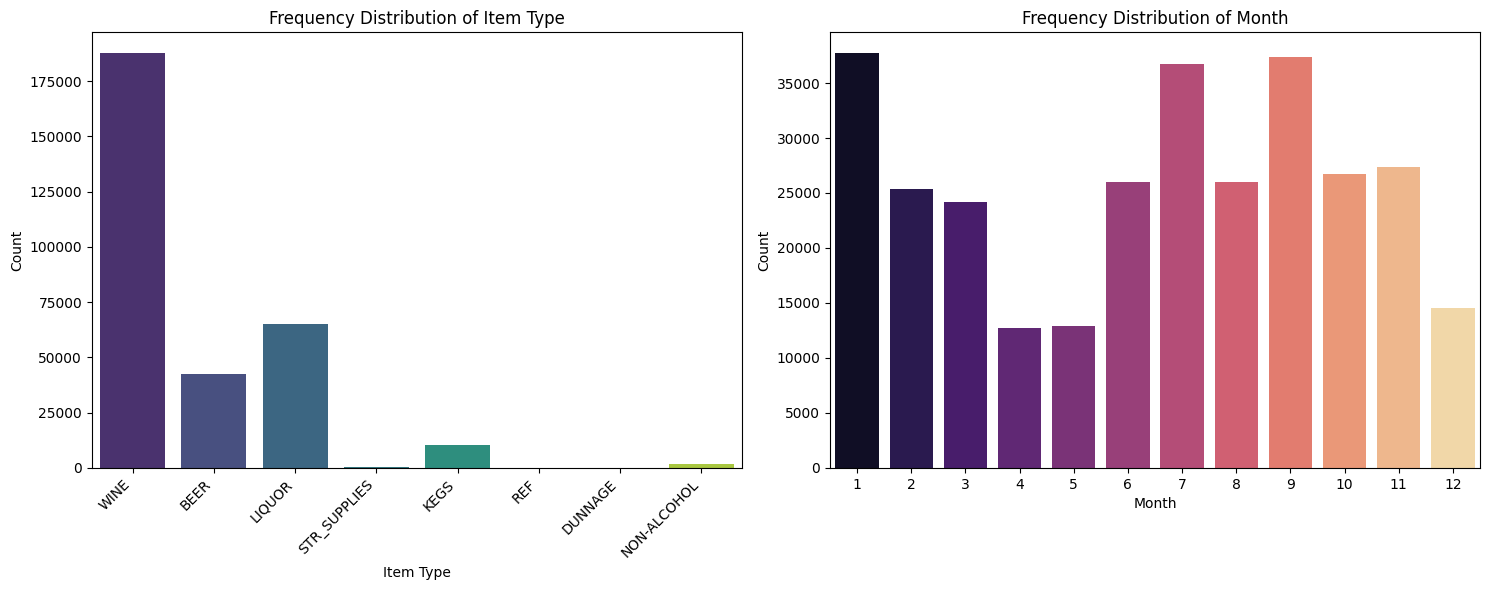

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Count plot for 'ITEM TYPE'
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='ITEM TYPE', palette='viridis')
plt.title('Frequency Distribution of Item Type')
plt.xlabel('Item Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Count plot for 'MONTH'
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='MONTH', palette='magma')
plt.title('Frequency Distribution of Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Bivariate Analysis - Numerical Relationships

### Subtask:
Create scatter plots to explore the relationship between pairs of important numerical features (e.g., 'RETAIL SALES' vs. 'WAREHOUSE SALES')

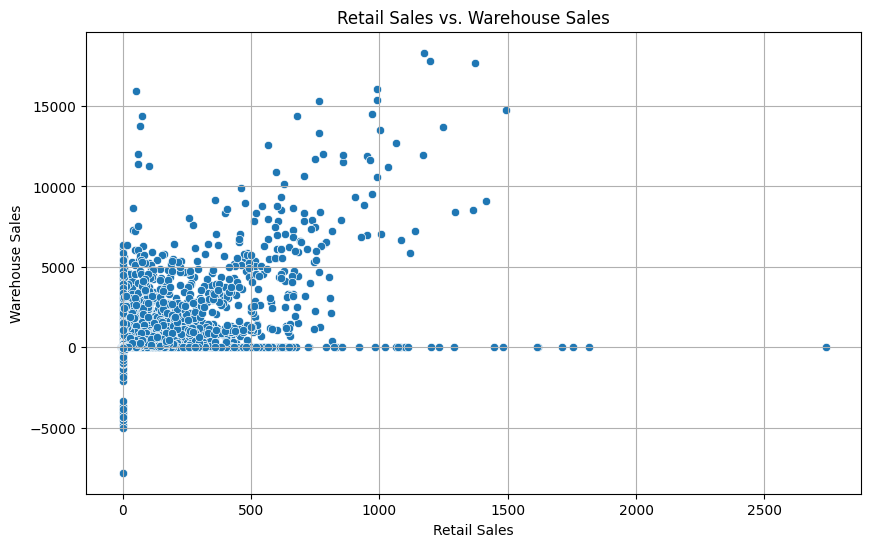

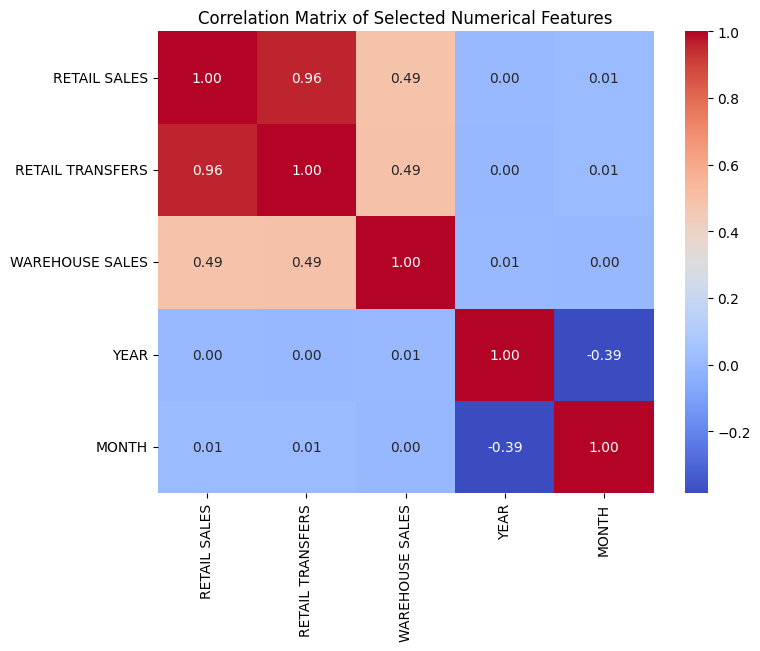

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a scatter plot for 'RETAIL SALES' vs. 'WAREHOUSE SALES'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='RETAIL SALES', y='WAREHOUSE SALES')
plt.title('Retail Sales vs. Warehouse Sales')
plt.xlabel('Retail Sales')
plt.ylabel('Warehouse Sales')
plt.grid(True)
plt.show()

# 2. Select numerical columns for correlation matrix
numerical_cols_for_corr = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES', 'YEAR', 'MONTH']
correlation_matrix = df[numerical_cols_for_corr].corr()

# 3. Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Selected Numerical Features')
plt.show()

## Bivariate Analysis - Numerical vs. Categorical

### Subtask:
Use box plots or violin plots to show the distribution of a key numerical feature (e.g., 'RETAIL SALES') across different categories of a categorical feature (e.g., 'ITEM TYPE').


/tmp/ipython-input-2194218826.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ITEM TYPE', y='RETAIL SALES', palette='coolwarm')


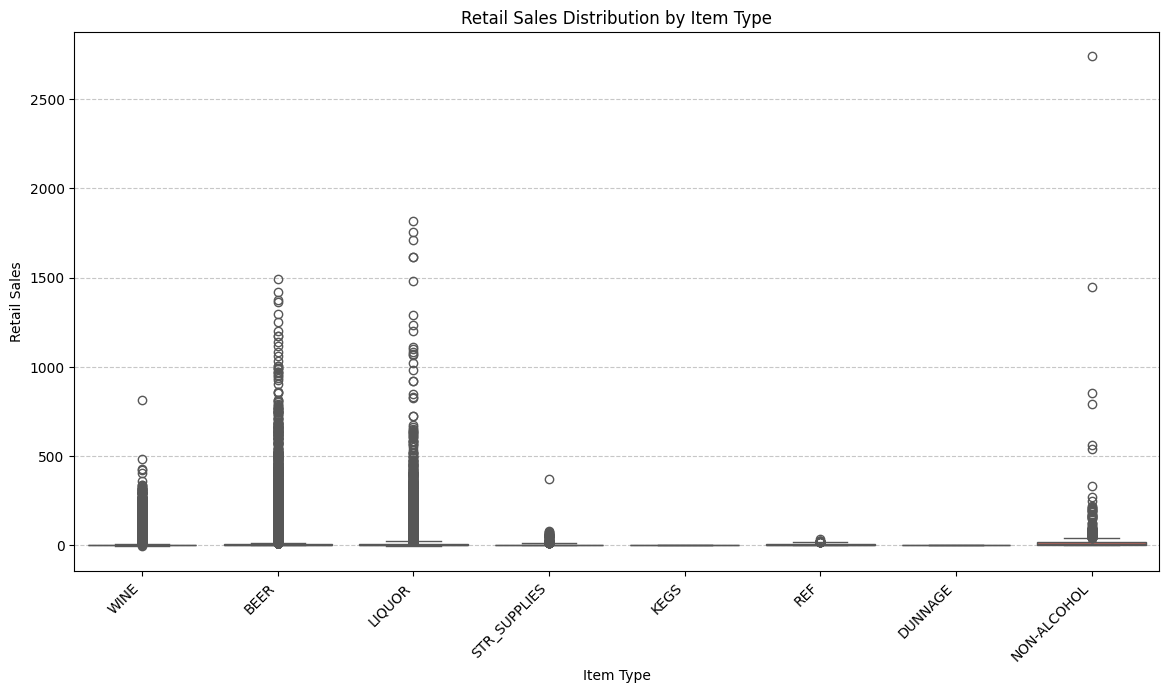

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to show the distribution of 'RETAIL SALES' by 'ITEM TYPE'
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='ITEM TYPE', y='RETAIL SALES', palette='coolwarm')
plt.title('Retail Sales Distribution by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Retail Sales')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` from Seaborn regarding the usage of `palette` without `hue`. To address this, I will assign the `x` variable ('ITEM TYPE') to `hue` and set `legend=False` as suggested by the warning.



# **Identify which numerical features may need scaling.**

After conducting the univariate and bivariate analyses, the numerical features that would most likely benefit from scaling are:

* RETAIL SALES

* RETAIL TRANSFERS:

* WAREHOUSE SALES:



# **Model Thinking**

 *  **RETAIL SALES**

 *  **The RETAIL SALES is a numerical variable,so the problem type is Regression.**